In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

In [54]:
TRAIN_PATH = "Data_path/data/data/train"
TEST_PATH = "Data_path/data/data/test"
LABELS = "Data_path/labeled_anomalies.csv"

In [55]:
df_anomalies = pd.read_csv(LABELS)

In [56]:
df_anomalies.info()
df_anomalies.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   chan_id            82 non-null     str  
 1   spacecraft         82 non-null     str  
 2   anomaly_sequences  82 non-null     str  
 3   class              82 non-null     str  
 4   num_values         82 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.3 KB


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


Description of labels:

- **channel_id** is the id related to a telemetry acquired by spacecraft/staellite;
- **spacecraft** could be SMAP or MSL;
- **anomaly_sequence** is telling windows corresponding to an anomalies inside that telemetry;
- **class** is telling which type of anomaly is: a *point anomaly* can be identified by properly set alarms or distance-based methods that ignore temporal information, *contextual* require more complex methodologies such as LSTMs or Hierarchical Temporal Memory (HTM) approaches;
- **num_values** is telling how many timestamps of observations the telemetry has.

Description of train/test:
In practice, each channel of train/test is a telemetry, and each telemetry is a **temporal matrix** containing T(num_values) x 25(channels of each variable) samples. 

**However, the first channel (channel 0) is the main one capturing the signal while other are auxilisry channels recording, for instace, commands given to satellite, hence all values inside other channels are almost always 0.**

From now on, we will use "channel" as equivalence of "feature" of each telemtry, which should not be confuse with "channel_id" of the labels dataset, which is referred to telemetry itself.

In [57]:
df_SMAP_anomalies = df_anomalies[df_anomalies['spacecraft'] == 'SMAP']
print(len(df_SMAP_anomalies['chan_id'].unique()))

54


Selecting only SMAP spacecraft, we have 54 telemetries, we probably should work with one at the time. Let's see how an anomaly is made:

In [58]:
np.random.seed(26)
telemetry_pos = np.random.randint(0,54)
print(telemetry_pos)

telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(telemetry_name)

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')
print(test_data.shape)

53
A-9
(8434, 25)


In [59]:
anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(anomaly)

anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1]) #just to plot

[[4569 8433]]


We visualize only three channels out of 25

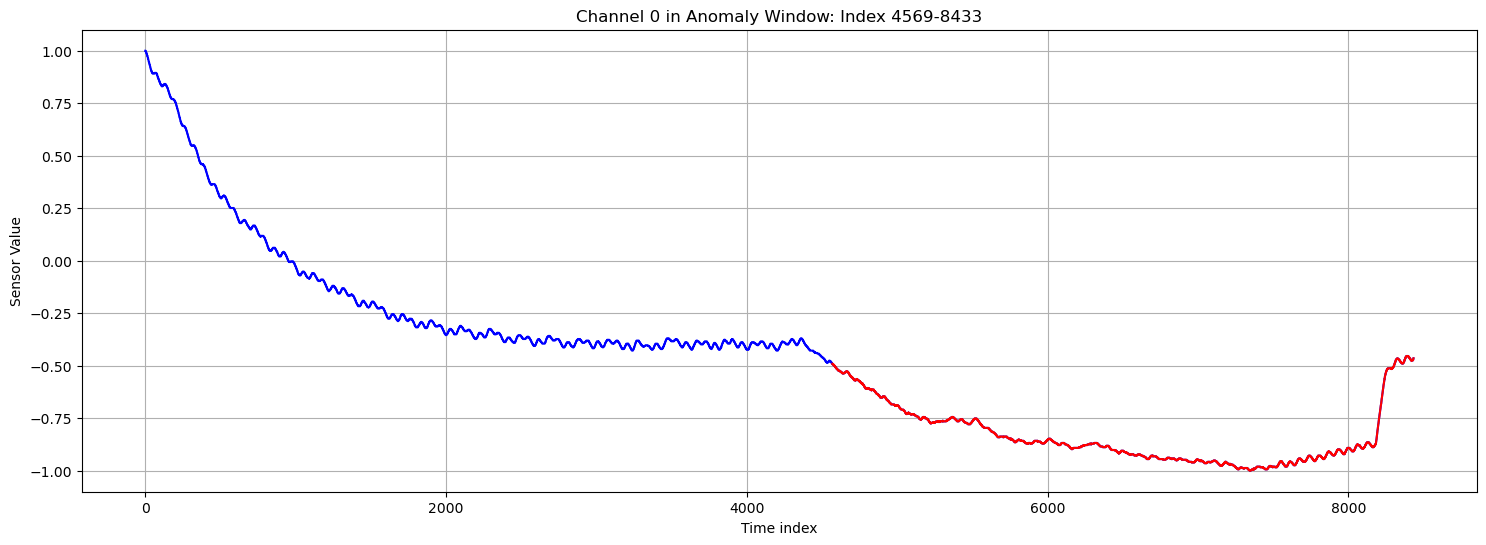

In [60]:
plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

This is a **contextual** anomaly as an anomalous trend appears in telemeyry.

## PREPROCESSING

1. EDA iniziale sui file train
2. controllo NaN / Inf
3. controllo feature costanti
4. rimozione feature costanti
5. split temporale train / validation
6. scaling fit solo sul train
7. PCA opzionale fit solo sul train
8. windowing

First we apply preprocessing pipeline on training set, then in test set.

In [61]:
smap_labels = df_SMAP_anomalies.copy()
smap_channels_ids = sorted(smap_labels['chan_id'].unique())

In [62]:
train_summary = []

for ch in smap_channels_ids:
    path = TRAIN_PATH + '/' + ch + '.npy'
    X = np.load(path)
    
    feature_std = np.nanstd(X, axis=0) #std among columns, nanstd ignores nan val
    
    train_summary.append({
        "channel_id": ch,
        "train_len": X.shape[0],
        "n_features": X.shape[1],
        "nan_count": int(np.isnan(X).sum()),
        "inf_count": int(np.isinf(X).sum()),
        "constant_features": int((feature_std == 0).sum()),
        "min": float(np.nanmin(X)),
        "max": float(np.nanmax(X)),
        "mean": float(np.nanmean(X)),
        "std": float(np.nanstd(X)),
    })

train_summary_df = pd.DataFrame(train_summary)
train_summary_df

,channel_id,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
0,A-1,2880,25,0,0,6,0.00,1.0,0.061654,0.240444
1,A-2,2648,25,0,0,7,-1.00,1.0,0.023143,0.186151
2,A-3,2736,25,0,0,7,-1.00,1.0,0.023542,0.173959
3,A-4,2690,25,0,0,7,-1.00,1.0,0.025349,0.163677
4,A-5,705,25,0,0,14,-1.00,1.0,-0.028584,0.224864
5,A-6,682,25,0,0,14,-1.00,1.0,-0.021383,0.200291
6,A-7,2879,25,0,0,15,-1.00,1.0,-0.011630,0.103913
7,A-8,762,25,0,0,15,-1.00,1.0,-0.007294,0.206191
8,A-9,762,25,0,0,15,-1.00,1.0,0.012211,0.204854
9,B-1,2435,25,0,0,13,-1.00,1.0,-0.035992,0.206671


The preliminary inspection of the SMAP training set shows that the data are generally clean from a missing-value perspective. No NaN or infinite values were found across the considered telemetry channels, so no imputation or removal of corrupted samples is required at this stage.

However, the dataset presents some relevant preprocessing issues. First, the telemetry streams have *different temporal* lengths: most channels contain around 2600–2880 time steps, while some channels are much shorter. This affects the windowing procedure, because shorter series generate fewer training windows and may be less informative for sequence-based models.

Second, all channels have 25 features, but several of these features *are constant over time* within each channel. In some cases, only a few features are constant, while in others almost all features do not vary. This is important because **constant features do not carry temporal information and may unnecessarily increase the dimensionality of the input**. They can also affect scaling and model training if not handled explicitly. --> `PCA`

A special case is represented by channels such as `D-12` and `D-13`, where all 25 features are constant over time. This does not necessarily mean that the whole matrix contains a single repeated value: different columns may have different constant values. However, from a temporal modeling perspective, these channels contain no dynamic information in the training set, and therefore require special attention.

In [63]:
train_summary_df.describe()

,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
count,54.000000,54.0,54.0,54.0,54.000000,54.000000,54.000000,54.000000,54.000000
mean,2555.629630,25.0,0.0,0.0,10.388889,-0.857037,0.962963,0.005461,0.200148
std,656.221784,0.0,0.0,0.0,5.137420,0.333747,0.190626,0.027075,0.041398
min,312.000000,25.0,0.0,0.0,6.000000,-1.000000,0.000000,-0.040000,0.074036
25%,2596.000000,25.0,0.0,0.0,7.000000,-1.000000,1.000000,-0.016257,0.175010
50%,2851.000000,25.0,0.0,0.0,7.000000,-1.000000,1.000000,0.003124,0.201878
75%,2880.000000,25.0,0.0,0.0,12.750000,-1.000000,1.000000,0.023131,0.240640
max,2881.000000,25.0,0.0,0.0,25.000000,0.000000,1.000000,0.063826,0.252260


The preprocessing pipeline is applied independently to each SMAP telemetry channel. 
First, the original training sequence is split into training and validation subsets using a temporal split, without shuffling, in order to avoid temporal leakage. Constant features are detected only on the training subset and then removed from both training and validation data. This avoids using information from the validation period during feature selection.

After removing constant features, the remaining variables are standardized using a StandardScaler fitted only on the training subset. The same transformation is then applied to the validation subset. Optionally, PCA can be fitted on the standardized training data and applied to validation data, in order to reduce dimensionality while preserving a fixed fraction of the variance.

Finally, both training and validation sequences are converted into overlapping temporal windows, which represent the input format required by sequence-based reconstruction or forecasting models.

In [64]:
def temporal_train_val_split(X, val_ratio=0.2):
    """
    Temporal split: first part for training, last part for validation.
    """
    split_idx = int(len(X) * (1 - val_ratio))
    X_train = X[:split_idx]
    X_val = X[split_idx:]
    
    return X_train, X_val

def make_windows(X, window_size=30, stride=1):
    """
    Convert a time series X of shape (T, d)
    into windows of shape (n_windows, window_size, d).
    """
    if len(X) < window_size:
        return None
    
    windows = []
    
    for start in range(0, len(X) - window_size + 1, stride):
        end = start + window_size
        windows.append(X[start:end])
    
    return np.stack(windows)

### Windowing

After the temporal split, each telemetry sequence is converted into overlapping time windows. This step is needed because the model should not observe each time step independently, but should instead learn short temporal patterns in the recent history of the signal.

Given a preprocessed sequence:

$X \in \mathbb{R}^{T \times d}$

where T is the number of time steps and d is the number of retained features, we construct windows of length w:

$W_t = [X_t, X_{t+1}, \dots, X_{t+w-1}]$

Each window therefore has shape:

$w \times d$

In this project, we use `window_size = 30` and `stride = 1`, meaning that consecutive windows overlap and are shifted by one time step. Therefore, the number of generated windows is:

$N_{\text{windows}} = T - w + 1$

#### Choice of the stride

In the windowing procedure, the stride controls how far the sliding window is shifted at each step. With `stride = 1`, two consecutive windows overlap almost completely and differ by only one time step. This produces the maximum number of training samples and preserves the highest temporal resolution.

This choice is suitable for anomaly detection because anomalies may be short, localized, or only visible in a narrow temporal region. Using a larger stride would reduce the number of windows and the computational cost, but it could also make the model less sensitive to short anomalous intervals or produce less precise anomaly localization.

Since the SMAP telemetry sequences are not extremely large, using `stride = 1` is a reasonable default choice for the first version of the pipeline. Larger strides can be considered as a computationally cheaper alternative and compared in an ablation study, for example by testing whether `stride = 5` significantly reduces performance while decreasing the number of generated windows.

For example, if a training split contains 2304 time steps and the window size is 30, the number of windows is:

$ 2304 - 30 + 1 = 2275 $

The final input shape for a channel is therefore:

$N_{\text{windows}} \times 30 \times d$

This representation allows the model to learn temporal dependencies and local patterns in the telemetry stream, which is essential for detecting anomalies that may not be visible from a single isolated time step.

In [65]:
def preprocess_single_channel(
    channel_id,
    train_path,
    val_ratio=0.2,
    window_size=30,
    stride=1,
    drop_constant_features=True,
    use_pca=False,
    pca_variance=0.95
):
    # -------------------------
    # Load raw training sequence
    # -------------------------
    path = train_path + "/" + channel_id + ".npy"
    X_raw = np.load(path)
    
    # -------------------------
    # Basic checks
    # -------------------------
    nan_count = np.isnan(X_raw).sum()
    inf_count = np.isinf(X_raw).sum()
    
    if nan_count > 0:
        raise ValueError(f"{channel_id}: NaN values found.")
    
    if inf_count > 0:
        raise ValueError(f"{channel_id}: infinite values found.")
    
    # -------------------------
    # Temporal train/validation split
    # -------------------------
    X_train_raw, X_val_raw = temporal_train_val_split(X_raw, val_ratio=val_ratio)
    
    # -------------------------
    # Detect constant features on TRAIN only
    # -------------------------
    feature_std_train = np.std(X_train_raw, axis=0)
    constant_mask = feature_std_train == 0
    keep_mask = ~constant_mask
    
    n_constant_features = int(constant_mask.sum())
    constant_feature_indices = np.where(constant_mask)[0]
    kept_feature_indices = np.where(keep_mask)[0]
    
    # If all features are constant, skip this channel
    if keep_mask.sum() == 0:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_all_features_constant",
            "raw_shape": X_raw.shape,
            "n_constant_features": n_constant_features,
            "constant_feature_indices": constant_feature_indices,
        }
    
    # -------------------------
    # Drop constant features
    # -------------------------
    if drop_constant_features:
        X_train_raw = X_train_raw[:, keep_mask]
        X_val_raw = X_val_raw[:, keep_mask]
    else:
        kept_feature_indices = np.arange(X_raw.shape[1])
    
    # -------------------------
    # Scaling: fit only on train
    # -------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_val_scaled = scaler.transform(X_val_raw)
    
    # -------------------------
    # Optional PCA: fit only on train
    # -------------------------
    pca = None
    
    if use_pca:
        pca = PCA(n_components=pca_variance)
        X_train_processed = pca.fit_transform(X_train_scaled)
        X_val_processed = pca.transform(X_val_scaled)
        n_components_pca = pca.n_components_
        explained_variance = float(pca.explained_variance_ratio_.sum())
    else:
        X_train_processed = X_train_scaled
        X_val_processed = X_val_scaled
        n_components_pca = np.NaN
        explained_variance = None
    
    # -------------------------
    # Windowing
    # -------------------------
    X_train_win = make_windows(X_train_processed, window_size=window_size, stride=stride)
    X_val_win = make_windows(X_val_processed, window_size=window_size, stride=stride)
    
    if X_train_win is None or X_val_win is None:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_too_short_after_split",
            "raw_shape": X_raw.shape,
            "train_shape": X_train_processed.shape,
            "val_shape": X_val_processed.shape,
        }
    
    # -------------------------
    # Output dictionary
    # -------------------------
    data = {
        "X_train": X_train_win,
        "X_val": X_val_win,
        "scaler": scaler,
        "pca": pca,
        "kept_feature_indices": kept_feature_indices,
        "constant_feature_indices": constant_feature_indices,
    }
    
    info = {
        "channel_id": channel_id,
        "status": "ok",
        "raw_shape": X_raw.shape,
        "train_raw_shape": X_train_raw.shape,
        "val_raw_shape": X_val_raw.shape,
        "train_windows_shape": X_train_win.shape,
        "val_windows_shape": X_val_win.shape,
        "n_original_features": int(X_raw.shape[1]),
        "n_constant_features": n_constant_features,
        "n_kept_features": len(kept_feature_indices),
        "use_pca": use_pca,
        "n_components_after_pca": n_components_pca,
        "pca_explained_variance": explained_variance,
    }
    
    return data, info

We try first without PCA, then with PCA.

In [66]:
VAL_RATIO = 0.2
WINDOW_SIZE = 30
STRIDE = 1

USE_PCA = False          
PCA_VARIANCE = 0.95
DROP_CONSTANT_FEATURES = True

preprocessed_data = {}
preprocessing_summary = []

for ch in smap_channels_ids:
    data, info = preprocess_single_channel(
        channel_id=ch,
        train_path=TRAIN_PATH,
        val_ratio=VAL_RATIO,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        drop_constant_features=DROP_CONSTANT_FEATURES,
        use_pca=USE_PCA,
        pca_variance=PCA_VARIANCE
    )
    
    preprocessing_summary.append(info)
    
    if data is not None:
        preprocessed_data[ch] = data

preprocessing_summary_df = pd.DataFrame(preprocessing_summary)

if "constant_feature_indices" in preprocessing_summary_df.columns:
    preprocessing_summary_df = preprocessing_summary_df.drop(columns=["constant_feature_indices"])

display(preprocessing_summary_df)

,channel_id,status,raw_shape,train_raw_shape,val_raw_shape,train_windows_shape,val_windows_shape,n_original_features,n_constant_features,n_kept_features,use_pca,n_components_after_pca,pca_explained_variance
0,A-1,ok,"(2880, 25)","(2304, 19)","(576, 19)","(2275, 30, 19)","(547, 30, 19)",25.0,6,19.0,False,NaN,NaN
1,A-2,ok,"(2648, 25)","(2118, 18)","(530, 18)","(2089, 30, 18)","(501, 30, 18)",25.0,7,18.0,False,NaN,NaN
2,A-3,ok,"(2736, 25)","(2188, 18)","(548, 18)","(2159, 30, 18)","(519, 30, 18)",25.0,7,18.0,False,NaN,NaN
3,A-4,ok,"(2690, 25)","(2152, 18)","(538, 18)","(2123, 30, 18)","(509, 30, 18)",25.0,7,18.0,False,NaN,NaN
4,A-5,ok,"(705, 25)","(564, 11)","(141, 11)","(535, 30, 11)","(112, 30, 11)",25.0,14,11.0,False,NaN,NaN
5,A-6,ok,"(682, 25)","(545, 11)","(137, 11)","(516, 30, 11)","(108, 30, 11)",25.0,14,11.0,False,NaN,NaN
6,A-7,ok,"(2879, 25)","(2303, 10)","(576, 10)","(2274, 30, 10)","(547, 30, 10)",25.0,15,10.0,False,NaN,NaN
7,A-8,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 10)","(124, 30, 10)",25.0,15,10.0,False,NaN,NaN
8,A-9,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 10)","(124, 30, 10)",25.0,15,10.0,False,NaN,NaN
9,B-1,ok,"(2435, 25)","(1948, 12)","(487, 12)","(1919, 30, 12)","(458, 30, 12)",25.0,13,12.0,False,NaN,NaN


Each raw training sequence originally contains 25 features, but several features are constant over time within individual channels. These constant features were detected using only the training split and removed before scaling, in order to avoid adding non-informative dimensions to the model.

The temporal split preserves the chronological order of the data, using the first 80% of each sequence for training and the last 20% for validation. After feature filtering and standardization, the sequences were converted into overlapping windows of length 30. The resulting window shapes are consistent with the expected formula T - window_size + 1.

Most channels were successfully preprocessed. Channels `D-12` and `D-13` were skipped because all their features were constant in the training split, leaving no dynamic information to model. PCA was not applied in this preprocessing run, so the PCA-related columns are intentionally empty.

In [67]:
VAL_RATIO = 0.2
WINDOW_SIZE = 30
STRIDE = 1

USE_PCA = True          
PCA_VARIANCE = 0.95
DROP_CONSTANT_FEATURES = True

preprocessed_data_pca = {}
preprocessing_summary_pca = []

for ch in smap_channels_ids:
    data, info = preprocess_single_channel(
        channel_id=ch,
        train_path=TRAIN_PATH,
        val_ratio=VAL_RATIO,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        drop_constant_features=DROP_CONSTANT_FEATURES,
        use_pca=USE_PCA,
        pca_variance=PCA_VARIANCE
    )
    
    preprocessing_summary_pca.append(info)
    
    if data is not None:
        preprocessed_data_pca[ch] = data

pca_preprocessing_summary_df = pd.DataFrame(preprocessing_summary_pca)

if "constant_feature_indices" in pca_preprocessing_summary_df.columns:
    pca_preprocessing_summary_df = pca_preprocessing_summary_df.drop(columns=["constant_feature_indices"])

display(pca_preprocessing_summary_df)

,channel_id,status,raw_shape,train_raw_shape,val_raw_shape,train_windows_shape,val_windows_shape,n_original_features,n_constant_features,n_kept_features,use_pca,n_components_after_pca,pca_explained_variance
0,A-1,ok,"(2880, 25)","(2304, 19)","(576, 19)","(2275, 30, 10)","(547, 30, 10)",25.0,6,19.0,True,10.0,0.953481
1,A-2,ok,"(2648, 25)","(2118, 18)","(530, 18)","(2089, 30, 10)","(501, 30, 10)",25.0,7,18.0,True,10.0,0.952515
2,A-3,ok,"(2736, 25)","(2188, 18)","(548, 18)","(2159, 30, 11)","(519, 30, 11)",25.0,7,18.0,True,11.0,0.969732
3,A-4,ok,"(2690, 25)","(2152, 18)","(538, 18)","(2123, 30, 11)","(509, 30, 11)",25.0,7,18.0,True,11.0,0.969603
4,A-5,ok,"(705, 25)","(564, 11)","(141, 11)","(535, 30, 6)","(112, 30, 6)",25.0,14,11.0,True,6.0,0.973347
5,A-6,ok,"(682, 25)","(545, 11)","(137, 11)","(516, 30, 6)","(108, 30, 6)",25.0,14,11.0,True,6.0,0.979794
6,A-7,ok,"(2879, 25)","(2303, 10)","(576, 10)","(2274, 30, 5)","(547, 30, 5)",25.0,15,10.0,True,5.0,0.959660
7,A-8,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 5)","(124, 30, 5)",25.0,15,10.0,True,5.0,0.952474
8,A-9,ok,"(762, 25)","(609, 10)","(153, 10)","(580, 30, 5)","(124, 30, 5)",25.0,15,10.0,True,5.0,0.952474
9,B-1,ok,"(2435, 25)","(1948, 12)","(487, 12)","(1919, 30, 7)","(458, 30, 7)",25.0,13,12.0,True,7.0,0.960908


In this preprocessing run, PCA was applied after the temporal train/validation split, after removing constant features, and after standardization. This is the correct order, because the PCA basis must be fitted only on the training split in order to avoid information leakage from the validation period.

The table shows that PCA further reduces the dimensionality of each telemetry channel while preserving approximately 95% of the variance. For example, channel `A-1` goes from 25 original features to 19 non-constant features, and then to 10 PCA components. Similarly, `A-5` goes from 25 original features to 11 retained features and then to 6 PCA components.

The column `pca_explained_variance` confirms that the retained PCA components preserve the target amount of variance. In most channels, the explained variance is slightly above 0.95, as expected. Some channels, such as `G-7` and `T-1`, reach an explained variance of 1.0 because they already have very few non-constant features after feature filtering.

The resulting window shapes reflect the PCA-reduced feature space. For instance, `A-1` has training windows of shape `(2275, 30, 10)`, meaning 2275 windows, each containing 30 time steps and 10 PCA components. Therefore, the temporal dimension is preserved, while the feature dimension is compressed.

Channels `D-12` and `D-13` are still skipped because all their original features are constant in the training split. Since no informative feature remains after constant-feature removal, PCA cannot be applied to these channels.

Overall, PCA provides a more compact representation of the telemetry streams, reducing input dimensionality while retaining most of the variance. This can reduce model complexity and computational cost, **but it should be compared against the non-PCA version to check whether the dimensionality reduction preserves anomaly-relevant information.**

Now we move to test_data preprocessing.

In [68]:
def parse_anomaly_sequences(x):
    """
    Convert anomaly_sequences from string format to Python list.
    """
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

def build_binary_labels(length, anomaly_sequences):
    """
    Convert anomaly intervals into a binary vector.
    1 = anomalous timestep, 0 = normal timestep.
    """
    y = np.zeros(length, dtype=int)

    for start, end in anomaly_sequences:
        start = max(0, int(start))
        end = min(length - 1, int(end))
        y[start:end + 1] = 1

    return y

def align_labels_to_windows(y, window_size=30, stride=1, mode="last"):
    """
    Align point-wise labels with temporal windows.
    mode='last': window label = label of the last timestep.
    mode='any': window label = 1 if at least one timestep in the window is anomalous.
    """
    labels = []

    for start in range(0, len(y) - window_size + 1, stride):
        end = start + window_size

        if mode == "last":
            labels.append(y[end - 1])
        elif mode == "any":
            labels.append(int(y[start:end].max() == 1))
        else:
            raise ValueError("mode must be 'last' or 'any'")

    return np.array(labels, dtype=int)

### Test label construction and window alignment

The function `build_binary_labels` converts the anomaly intervals provided in the metadata into a point-wise binary label vector. The original labels are given as intervals `[start, end]`, meaning that all time steps between `start` and `end` are anomalous. Therefore, for a test sequence of length T, the function creates a vector:

$y \in \{0,1\}^{T}$

where $y_t = 1$ if time step t belongs to an anomalous interval, and $y_t = 0$ otherwise. The interval boundaries are clipped to remain inside the valid range of the test sequence.

The function `align_labels_to_windows` then aligns these point-wise labels with the windowed representation of the data. Since the model receives windows rather than individual time steps, each window must be assigned a single binary label.
Two labeling strategies are supported. With `mode="last"`, the label of a window is the label of its last time step. This is a clean and temporally causal choice, because the window is associated with the state reached at its endpoint. With `mode="any"`, a window is labeled as anomalous if at least one time step inside the window is anomalous. This strategy is more sensitive, but it may label a window as anomalous even when the anomaly occurs only in a small part of the window.

In the main pipeline, `mode="last"` is used as the default choice because it preserves a direct alignment between each window and the final time step represented by that window.

In [69]:
def preprocess_test_channel(
    channel_id,
    test_path,
    labels_df,
    train_preprocessed_data,
    window_size=30,
    stride=1,
    label_mode="last"
):
    # If the channel was skipped during train preprocessing, skip it also in test
    if channel_id not in train_preprocessed_data:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_no_train_preprocessing"
        }

    # Load raw test sequence
    path = test_path + "/" + channel_id + ".npy"
    X_test_raw = np.load(path)

    # Basic checks
    nan_count = np.isnan(X_test_raw).sum()
    inf_count = np.isinf(X_test_raw).sum()

    if nan_count > 0:
        raise ValueError(f"{channel_id}: NaN values found in test data.")

    if inf_count > 0:
        raise ValueError(f"{channel_id}: infinite values found in test data.")

    # Retrieve transformations fitted on train
    train_info = train_preprocessed_data[channel_id]

    kept_feature_indices = train_info["kept_feature_indices"]
    scaler = train_info["scaler"]
    pca = train_info["pca"]

    # Apply same feature selection used on train
    X_test_selected = X_test_raw[:, kept_feature_indices]

    # Apply scaler FITTED ON TRAIN, hence only tranfrom applied
    X_test_scaled = scaler.transform(X_test_selected)

    # Apply PCA FITTED ON TRAIN, if present
    if pca is not None:
        X_test_processed = pca.transform(X_test_scaled)
        use_pca = True
    else:
        X_test_processed = X_test_scaled
        use_pca = False

    # Windowing
    X_test_win = make_windows(
        X_test_processed,
        window_size=window_size,
        stride=stride
    )

    if X_test_win is None:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_test_too_short",
            "raw_shape": X_test_raw.shape,
            "processed_shape": X_test_processed.shape
        }

    # Retrieve and merge anomaly intervals
    rows = labels_df[labels_df["chan_id"] == channel_id]

    if len(rows) == 0:
        raise ValueError(f"{channel_id}: no labels found.")

    anomaly_sequences = []
    for seq in rows["anomaly_sequences"]:
        anomaly_sequences.extend(seq)

    # Build raw timestep labels
    y_test_raw = build_binary_labels(
        length=len(X_test_raw),
        anomaly_sequences=anomaly_sequences
    )

    # Align labels to windows
    y_test_win = align_labels_to_windows(
        y_test_raw,
        window_size=window_size,
        stride=stride,
        mode=label_mode
    )

    assert len(X_test_win) == len(y_test_win), (
        f"{channel_id}: mismatch between test windows and labels. "
        f"{len(X_test_win)} vs {len(y_test_win)}"
    )

    data = {
        "X_test": X_test_win,
        "y_test": y_test_win,
        "y_test_raw": y_test_raw,
        "anomaly_sequences": anomaly_sequences,
    }

    info = {
        "channel_id": channel_id,
        "status": "ok",
        "raw_shape": X_test_raw.shape,
        "processed_shape": X_test_processed.shape,
        "test_windows_shape": X_test_win.shape,
        "y_test_shape": y_test_win.shape,
        "n_anomaly_points_raw": int(y_test_raw.sum()),
        "anomaly_ratio_raw": float(y_test_raw.mean()),
        "n_anomaly_windows": int(y_test_win.sum()),
        "anomaly_ratio_windows": float(y_test_win.mean()),
        "use_pca": use_pca,
        "label_mode": label_mode,
    }

    return data, info

In [70]:
df_SMAP_anomalies_clean = df_SMAP_anomalies.copy()

df_SMAP_anomalies_clean["anomaly_sequences"] = (
    df_SMAP_anomalies_clean["anomaly_sequences"].apply(parse_anomaly_sequences))

Again, first with PCA then without.

In [71]:
test_preprocessed_data = {}
test_preprocessing_summary = []

for ch in smap_channels_ids:
    data, info = preprocess_test_channel(
        channel_id=ch,
        test_path=TEST_PATH,
        labels_df= df_SMAP_anomalies_clean,
        train_preprocessed_data=preprocessed_data,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        label_mode="last"
    )

    test_preprocessing_summary.append(info)

    if data is not None:
        test_preprocessed_data[ch] = data

test_preprocessing_summary_df = pd.DataFrame(test_preprocessing_summary)
display(test_preprocessing_summary_df)

,channel_id,status,raw_shape,processed_shape,test_windows_shape,y_test_shape,n_anomaly_points_raw,anomaly_ratio_raw,n_anomaly_windows,anomaly_ratio_windows,use_pca,label_mode
0,A-1,ok,"(8640, 25)","(8640, 19)","(8611, 30, 19)","(8611,)",85.0,0.009838,85.0,0.009871,False,last
1,A-2,ok,"(7914, 25)","(7914, 18)","(7885, 30, 18)","(7885,)",111.0,0.014026,111.0,0.014077,False,last
2,A-3,ok,"(8205, 25)","(8205, 18)","(8176, 30, 18)","(8176,)",186.0,0.022669,186.0,0.022750,False,last
3,A-4,ok,"(8080, 25)","(8080, 18)","(8051, 30, 18)","(8051,)",111.0,0.013738,111.0,0.013787,False,last
4,A-5,ok,"(4693, 25)","(4693, 11)","(4664, 30, 11)","(4664,)",51.0,0.010867,51.0,0.010935,False,last
5,A-6,ok,"(4453, 25)","(4453, 11)","(4424, 30, 11)","(4424,)",41.0,0.009207,41.0,0.009268,False,last
6,A-7,ok,"(8631, 25)","(8631, 10)","(8602, 30, 10)","(8602,)",2401.0,0.278183,2401.0,0.279121,False,last
7,A-8,ok,"(8375, 25)","(8375, 10)","(8346, 30, 10)","(8346,)",3806.0,0.454448,3806.0,0.456027,False,last
8,A-9,ok,"(8434, 25)","(8434, 10)","(8405, 30, 10)","(8405,)",3865.0,0.458264,3865.0,0.459845,False,last
9,B-1,ok,"(8044, 25)","(8044, 12)","(8015, 30, 12)","(8015,)",71.0,0.008826,71.0,0.008858,False,last


The test preprocessing is consistent with the transformations learned during the training preprocessing. For each telemetry channel, the same feature selection obtained from the training split is applied to the test sequence. For example, channel `A-1` is reduced from 25 original features to 19 retained features, matching the 6 constant features detected in the training data.

No preprocessing step is fitted on the test set. The scaler, the retained feature indices, and the optional PCA transformation are taken from the training preprocessing and only applied to the test data. This avoids information leakage and simulates a realistic deployment setting, where future telemetry must be processed using parameters estimated from past data.

The windowing step is also consistent with the training pipeline. With `window_size = 30` and `stride = 1`, a test sequence of length T produces $T - 30 + 1$ windows. For instance, `A-1` has 8640 test time steps and therefore produces 8611 windows, each with shape $30 \times 19$.

Channels `D-12` and `D-13` are skipped because they were already excluded during training preprocessing: all their features were constant in the training split, leaving no dynamic information to model.

Finally, the anomaly intervals provided in the metadata are converted into binary timestep labels and then aligned with the generated windows. Since `label_mode = "last"` is used, each window receives the label of its final timestep. The resulting anomaly ratios show strong variability across telemetry channels, confirming that the evaluation should not rely on accuracy alone but should consider precision, recall, F1-score, and possibly per-channel analysis.

In [72]:
test_preprocessed_data_pca = {}
test_preprocessing_summary_pca = []

for ch in smap_channels_ids:
    data, info = preprocess_test_channel(
        channel_id=ch,
        test_path=TEST_PATH,
        labels_df= df_SMAP_anomalies_clean,
        train_preprocessed_data=preprocessed_data_pca,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        label_mode="last"
    )

    test_preprocessing_summary_pca.append(info)

    if data is not None:
        test_preprocessed_data_pca[ch] = data

pca_test_preprocessing_summary_df = pd.DataFrame(test_preprocessing_summary_pca)
display(pca_test_preprocessing_summary_df)

,channel_id,status,raw_shape,processed_shape,test_windows_shape,y_test_shape,n_anomaly_points_raw,anomaly_ratio_raw,n_anomaly_windows,anomaly_ratio_windows,use_pca,label_mode
0,A-1,ok,"(8640, 25)","(8640, 10)","(8611, 30, 10)","(8611,)",85.0,0.009838,85.0,0.009871,True,last
1,A-2,ok,"(7914, 25)","(7914, 10)","(7885, 30, 10)","(7885,)",111.0,0.014026,111.0,0.014077,True,last
2,A-3,ok,"(8205, 25)","(8205, 11)","(8176, 30, 11)","(8176,)",186.0,0.022669,186.0,0.022750,True,last
3,A-4,ok,"(8080, 25)","(8080, 11)","(8051, 30, 11)","(8051,)",111.0,0.013738,111.0,0.013787,True,last
4,A-5,ok,"(4693, 25)","(4693, 6)","(4664, 30, 6)","(4664,)",51.0,0.010867,51.0,0.010935,True,last
5,A-6,ok,"(4453, 25)","(4453, 6)","(4424, 30, 6)","(4424,)",41.0,0.009207,41.0,0.009268,True,last
6,A-7,ok,"(8631, 25)","(8631, 5)","(8602, 30, 5)","(8602,)",2401.0,0.278183,2401.0,0.279121,True,last
7,A-8,ok,"(8375, 25)","(8375, 5)","(8346, 30, 5)","(8346,)",3806.0,0.454448,3806.0,0.456027,True,last
8,A-9,ok,"(8434, 25)","(8434, 5)","(8405, 30, 5)","(8405,)",3865.0,0.458264,3865.0,0.459845,True,last
9,B-1,ok,"(8044, 25)","(8044, 7)","(8015, 30, 7)","(8015,)",71.0,0.008826,71.0,0.008858,True,last


Compared to the non-PCA test preprocessing, the only additional transformation here is the projection onto the PCA space learned from the corresponding training split. The test data are therefore not only filtered using the same retained features and standardized with the train-fitted scaler, but also transformed using the PCA model fitted on the training data.

This is visible in the `processed_shape` and `test_windows_shape` columns. For example, `A-1` is reduced from 25 original features to 10 PCA components, producing test windows of shape `(8611, 30, 10)`. In the non-PCA version, the same channel retained 19 features after constant-feature removal. Thus, PCA further compresses the input representation while preserving the temporal structure of the data.

The anomaly labels and window alignment remain unchanged with respect to the non-PCA version. The number of anomalous raw points and anomalous windows is therefore the same, because PCA only affects the feature representation, not the temporal indexing or the label construction.

Channels `D-12` and `D-13` are still skipped because they were already excluded during training preprocessing. Since no informative non-constant features were available for these channels, no scaler or PCA transformation was fitted for them.

In [73]:
# Final checks

print('train_no_pca:',len(preprocessed_data))
print('train_pca:',len(preprocessed_data_pca))
print()
print('test_no_pca:',len(test_preprocessed_data))
print('test_pca:',len(test_preprocessed_data_pca))
print()
print(set(preprocessed_data.keys()) == set(test_preprocessed_data.keys()))
print(set(preprocessed_data_pca.keys()) == set(test_preprocessed_data_pca.keys()))

train_no_pca: 52
train_pca: 52

test_no_pca: 52
test_pca: 52

True
True


In [74]:
# check for a channel dimensions

ch = list(preprocessed_data.keys())[0]
print(preprocessed_data[ch]["X_train"].shape)
print(preprocessed_data[ch]["X_val"].shape)
print(test_preprocessed_data[ch]["X_test"].shape)
print(test_preprocessed_data[ch]["y_test"].shape)

print()

ch_pca = list(preprocessed_data_pca.keys())[0]
print(preprocessed_data[ch_pca]["X_train"].shape)
print(preprocessed_data[ch_pca]["X_val"].shape)
print(test_preprocessed_data[ch_pca]["X_test"].shape)
print(test_preprocessed_data[ch_pca]["y_test"].shape)

(2275, 30, 19)
(547, 30, 19)
(8611, 30, 19)
(8611,)

(2275, 30, 19)
(547, 30, 19)
(8611, 30, 19)
(8611,)


## BASELINE MODELS

Two baseline families are considered: **Isolation Forest** and a **forecasting-based model**.

**Isolation Forest** is selected as a simple unsupervised anomaly detection baseline. After preprocessing, each telemetry window is flattened and treated as a point in a high-dimensional feature space. The model then tries to identify windows that are easier to isolate from the rest of the training distribution. This makes it a reasonable first baseline because it does not require anomaly labels during training and can be applied directly to the windowed telemetry data.

Isolation Forest is useful as a comparison point because it mainly detects windows that are statistically rare with respect to the training data. However, *it does not explicitly model the temporal order inside each window* once the window is flattened. For this reason, it is a good lightweight baseline, *but it may miss anomalies that are mainly expressed through temporal dynamics* rather than isolated unusual values.

A **forecasting-based model** is introduced as a second baseline because the SMAP dataset is inherently temporal. In this approach, the model learns to predict the next telemetry state from a recent history window:

$[X_{t-w}, \dots, X_{t-1}] \rightarrow \hat{X}_t$

The anomaly score is then defined as the prediction error:

$s_t = \|X_t - \hat{X}_t\|^2$

The intuition is that normal telemetry should be predictable from its recent past, while anomalous behavior should produce larger forecasting errors.

Using both models provides a meaningful comparison between two perspectives: Isolation Forest treats each window as a rare-or-normal object in feature space, while the forecasting model explicitly evaluates whether the temporal evolution of the system is predictable. This allows us to assess whether modeling temporal dynamics improves anomaly detection compared to a simpler non-sequential baseline.

In [75]:
def flatten_windows(X):
    return X.reshape(X.shape[0], -1)

def compute_metrics(y_true, scores, threshold):
    y_pred = (scores < threshold).astype(int)

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, -scores),
        "threshold": threshold,
        "predicted_anomaly_ratio": float(y_pred.mean())
    }

### Evaluation metrics

The anomaly detector produces a continuous anomaly score for each test window. A binary prediction is obtained by applying a threshold: windows with a score below the threshold are classified as anomalous.

The selected metrics are **precision**, **recall**, **F1-score**, and **PR-AUC**. These metrics are more appropriate than accuracy because anomaly detection datasets are usually imbalanced: normal windows are often much more frequent than anomalous ones. In this setting, a model could obtain high accuracy simply by predicting most windows as normal, while still missing many anomalies.

**Precision** measures how many predicted anomalies are actually anomalous. It is useful to quantify the reliability of the alarms:

$\text{precision} = \frac{TP}{TP + FP}$

**Recall** measures how many true anomalies are detected. It is important because missing an anomalous telemetry interval may be more critical than raising a false alarm:

$\text{recall} = \frac{TP}{TP + FN}$

**F1-score** combines precision and recall into a single value, providing a balanced measure when both false positives and false negatives matter:

$F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$

**PR-AUC** evaluates the quality of the continuous anomaly scores across different possible thresholds. This is useful because the final performance can depend strongly on the selected threshold, and precision-recall curves are better suited than ROC curves when the positive class is rare.

The `predicted_anomaly_ratio` is also reported as a diagnostic quantity. It indicates the fraction of windows classified as anomalous and helps identify degenerate cases where a model predicts almost everything as normal or almost everything as anomalous.

In [76]:
def run_isolation_forest_channel(
    channel_id,
    train_data,
    test_data,
    threshold_quantile=0.01,
    n_estimators=200,
    contamination="auto",
    random_state=42
):
    X_train = flatten_windows(train_data[channel_id]["X_train"])
    X_val = flatten_windows(train_data[channel_id]["X_val"])
    X_test = flatten_windows(test_data[channel_id]["X_test"])
    y_test = test_data[channel_id]["y_test"]

    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(X_train)

    # In sklearn IsolationForest:
    # lower decision_function = more anomalous
    val_scores = model.decision_function(X_val)
    test_scores = model.decision_function(X_test)

    # Since lower score = more anomalous, use a low quantile
    threshold = np.quantile(val_scores, threshold_quantile)

    metrics = compute_metrics(y_test, test_scores, threshold)

    result = {
        "channel_id": channel_id,
        "model": "IsolationForest",
        "input_dim": X_train.shape[1],
        "n_train_windows": X_train.shape[0],
        "n_val_windows": X_val.shape[0],
        "n_test_windows": X_test.shape[0],
        "threshold_quantile": threshold_quantile,
        "n_estimators": n_estimators,
        "contamination": contamination,
        "score_direction": "lower_is_more_anomalous",
        **metrics
    }

    return result, test_scores

def run_isolation_forest_all_channels(
    train_data,
    test_data,
    setting_name,
    threshold_quantile=0.99
):
    results = []
    scores_dict = {}

    for ch in test_data.keys():
        result, scores = run_isolation_forest_channel(
            channel_id=ch,
            train_data=train_data,
            test_data=test_data,
            threshold_quantile=threshold_quantile
        )

        result["setting"] = setting_name
        results.append(result)
        scores_dict[ch] = scores

    return pd.DataFrame(results), scores_dict

### Isolation Forest scoring and threshold selection

Isolation Forest returns a **normality score** through its `decision_function`: higher values correspond to more normal samples, while lower values indicate more isolated and potentially anomalous samples.

$s(x) = \text{decision\_function}(x)$

The model is trained with `n_estimators = 200`, meaning that the Isolation Forest is composed of 200 isolation trees. This value is a reasonable compromise between stability and computational cost: using too few trees may produce noisy scores, while increasing the number of trees improves score stability but also increases runtime. Since the dataset is processed channel by channel and the input windows can be high-dimensional after flattening, 200 trees provide a sufficiently robust baseline without making the computation unnecessarily expensive.

The final binary anomaly prediction is obtained by applying a threshold to the normality scores. The threshold is not selected on the test set, in order to avoid information leakage. Instead, it is estimated from the validation scores:

$\tau = Q_{0.01}(s_{\text{val}})$

where $Q_{0.01}$ is the **1st percentile** of the validation normality scores. This means that a test window is classified as anomalous only if its normality score is lower than almost all scores observed on the validation set:

$\hat{y}_t = \begin{cases}
1 & \text{if } s_t < \tau \\
0 & \text{otherwise}
\end{cases}$

This choice reflects a semi-supervised anomaly detection setting: the model is trained on historical behavior, and the validation set is used to estimate the lower tail of scores that should still be considered normal. A low quantile such as 0.01 is conservative: it limits the number of false alarms, but it may reduce recall if some true anomalies do not produce extremely low normality scores.

For ranking-based metrics such as PR-AUC, the scores are inverted because these metrics assume that larger scores correspond to the positive class, i.e. the anomalous class. Therefore, PR-AUC is computed using $-s(x)$, while the binary thresholding rule uses the original normality score $s(x)$.

Overall, the quantile-based threshold should be interpreted as a simple baseline decision rule. It provides a transparent way to convert continuous normality scores into binary anomaly predictions, while more adaptive thresholding strategies can later be compared against it.

In [77]:
iforest_no_pca_df, iforest_no_pca_scores = run_isolation_forest_all_channels(
    train_data= preprocessed_data,
    test_data= test_preprocessed_data,
    setting_name="no_pca",
    threshold_quantile=0.99
)

iforest_pca_df, iforest_pca_scores = run_isolation_forest_all_channels(
    train_data= preprocessed_data_pca,
    test_data= test_preprocessed_data_pca,
    setting_name="pca",
    threshold_quantile=0.99
)

In [78]:
iforest_results_df = pd.concat(
    [iforest_no_pca_df, iforest_pca_df],
    ignore_index=True
)

display(iforest_results_df)

,channel_id,model,input_dim,n_train_windows,n_val_windows,n_test_windows,threshold_quantile,n_estimators,contamination,score_direction,precision,recall,f1,pr_auc,threshold,predicted_anomaly_ratio,setting
0,A-1,IsolationForest,570,2275,547,8611,0.99,200,auto,lower_is_more_anomalous,0.013282,0.858824,0.026160,0.007537,0.195069,0.638253,no_pca
1,A-2,IsolationForest,540,2089,501,7885,0.99,200,auto,lower_is_more_anomalous,0.014297,1.000000,0.028190,0.011359,0.184481,0.984654,no_pca
2,A-3,IsolationForest,540,2159,519,8176,0.99,200,auto,lower_is_more_anomalous,0.023140,1.000000,0.045233,0.019303,0.184957,0.983121,no_pca
3,A-4,IsolationForest,540,2123,509,8051,0.99,200,auto,lower_is_more_anomalous,0.013971,0.981982,0.027550,0.012858,0.185906,0.969072,no_pca
4,A-5,IsolationForest,330,535,112,4664,0.99,200,auto,lower_is_more_anomalous,0.010935,1.000000,0.021633,0.013611,0.189807,1.000000,no_pca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,R-1,IsolationForest,150,2270,546,7215,0.99,200,auto,lower_is_more_anomalous,0.000000,0.000000,0.000000,0.011227,0.204827,0.050173,pca
100,S-1,IsolationForest,300,2225,535,7302,0.99,200,auto,lower_is_more_anomalous,0.061447,0.993304,0.115735,0.070861,0.190280,0.991783,pca
101,T-1,IsolationForest,60,2271,546,8583,0.99,200,auto,lower_is_more_anomalous,0.161071,0.880859,0.272343,0.119156,0.120592,0.978679,pca
102,T-2,IsolationForest,240,2255,542,8596,0.99,200,auto,lower_is_more_anomalous,0.201618,0.963585,0.333463,0.161541,0.192132,0.992438,pca


In [79]:
iforest_results_df.groupby("setting")[[
    "precision", "recall", "f1", "pr_auc", "predicted_anomaly_ratio"
]].mean()

,precision,recall,f1,pr_auc,predicted_anomaly_ratio
setting,,,,,
no_pca,0.116866,0.742869,0.170912,0.152464,0.710274
pca,0.115806,0.784753,0.173873,0.215961,0.750171


In [88]:
def plot_iforest_scores_with_anomaly_regions(
    channel_id,
    scores_dict,
    test_data,
    results_df,
    figsize=(16, 5)
):
    scores = scores_dict[channel_id]
    y_true = test_data[channel_id]["y_test"]

    row = results_df[results_df["channel_id"] == channel_id].iloc[0]
    threshold = row["threshold"]

    plt.figure(figsize=figsize)

    plt.plot(scores, label="Isolation Forest normality score", linewidth=1)
    plt.axhline(threshold, linestyle="--", label="Threshold",color='red')

    in_anomaly = False
    start = None

    for i, value in enumerate(y_true):
        if value == 1 and not in_anomaly:
            start = i
            in_anomaly = True
        elif value == 0 and in_anomaly:
            plt.axvspan(start, i - 1, alpha=0.2)
            in_anomaly = False

    if in_anomaly:
        plt.axvspan(start, len(y_true) - 1, alpha=0.2)

    plt.title(f"Isolation Forest scores with true anomaly regions - Channel {channel_id}")
    plt.xlabel("Window index")
    plt.ylabel("Normality score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_score_distribution(
    channel_id,
    scores_dict,
    test_data,
    results_df,
    bins=50,
    figsize=(8, 5)
):
    scores = scores_dict[channel_id]
    y_true = test_data[channel_id]["y_test"]

    row = results_df[results_df["channel_id"] == channel_id].iloc[0]
    threshold = row["threshold"]

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    plt.figure(figsize=figsize)

    plt.hist(normal_scores, bins=bins, alpha=0.6, label="Normal windows")
    plt.hist(anomaly_scores, bins=bins, alpha=0.6, label="Anomalous windows")
    plt.axvline(threshold, linestyle="--", label="Threshold",color='red')

    plt.title(f"Score distribution - Channel {channel_id}")
    plt.xlabel("Anomaly score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curve(
    channel_id,
    scores_dict,
    test_data,
    figsize=(6, 5)
):
    scores = scores_dict[channel_id]
    y_true = test_data[channel_id]["y_test"]

    precision, recall, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)

    plt.figure(figsize=figsize)

    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall curve - Channel {channel_id}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_iforest_comparison_pca_vs_no_pca(
    channel_id,
    scores_no_pca,
    scores_pca,
    test_data_no_pca,
    results_no_pca,
    results_pca,
    figsize=(16, 5)
):
    s_no = scores_no_pca[channel_id]
    s_pca = scores_pca[channel_id]

    y_true = test_data_no_pca[channel_id]["y_test"]

    thr_no = results_no_pca[results_no_pca["channel_id"] == channel_id].iloc[0]["threshold"]
    thr_pca = results_pca[results_pca["channel_id"] == channel_id].iloc[0]["threshold"]

    s_no_norm = (s_no - s_no.min()) / (s_no.max() - s_no.min() + 1e-12)
    s_pca_norm = (s_pca - s_pca.min()) / (s_pca.max() - s_pca.min() + 1e-12)

    thr_no_norm = (thr_no - s_no.min()) / (s_no.max() - s_no.min() + 1e-12)
    thr_pca_norm = (thr_pca - s_pca.min()) / (s_pca.max() - s_pca.min() + 1e-12)

    plt.figure(figsize=figsize)

    plt.plot(s_no_norm, label="No PCA score", linewidth=1)
    plt.plot(s_pca_norm, label="PCA score", linewidth=1)

    plt.axhline(thr_no_norm, linestyle="--", label="No PCA threshold", color='red')
    plt.axhline(thr_pca_norm, linestyle="--", label="PCA threshold",color='green')

    in_anomaly = False
    start = None

    for i, value in enumerate(y_true):
        if value == 1 and not in_anomaly:
            start = i
            in_anomaly = True
        elif value == 0 and in_anomaly:
            plt.axvspan(start, i - 1, alpha=0.15)
            in_anomaly = False

    if in_anomaly:
        plt.axvspan(start, len(y_true) - 1, alpha=0.15)

    plt.title(f"Isolation Forest scores: no PCA vs PCA - Channel {channel_id}")
    plt.xlabel("Window index")
    plt.ylabel("Normalized anomaly score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

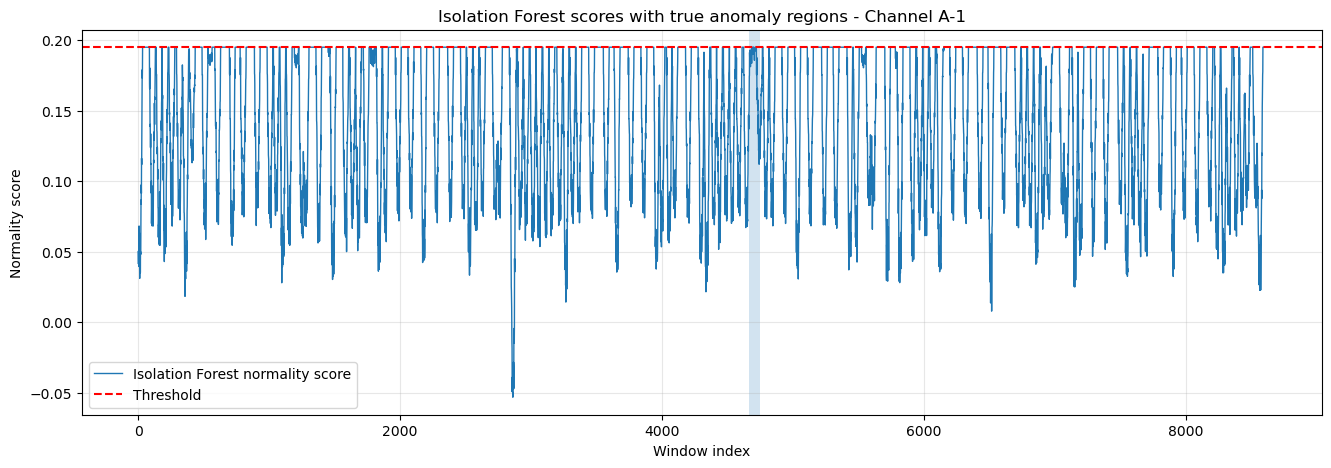

In [81]:
plot_iforest_scores_with_anomaly_regions(
    channel_id="A-1",
    scores_dict= iforest_no_pca_scores,
    test_data= test_preprocessed_data,
    results_df= iforest_no_pca_df,
)

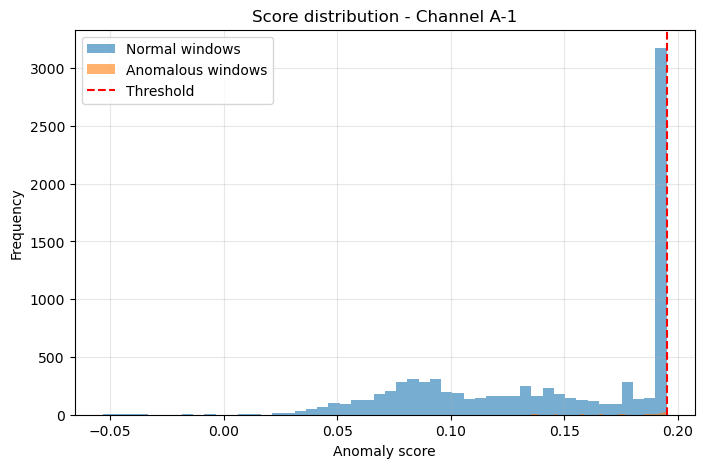

In [85]:
plot_score_distribution(
    channel_id="A-1",
    scores_dict=iforest_no_pca_scores,
    test_data=test_preprocessed_data,
    results_df=iforest_no_pca_df
)

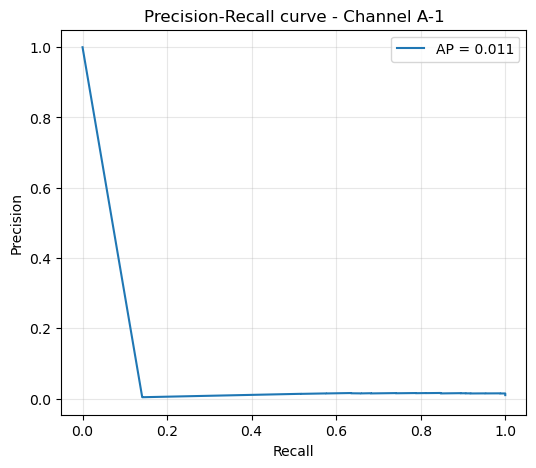

In [86]:
plot_pr_curve(
    channel_id="A-1",
    scores_dict=iforest_no_pca_scores,
    test_data=test_preprocessed_data
)

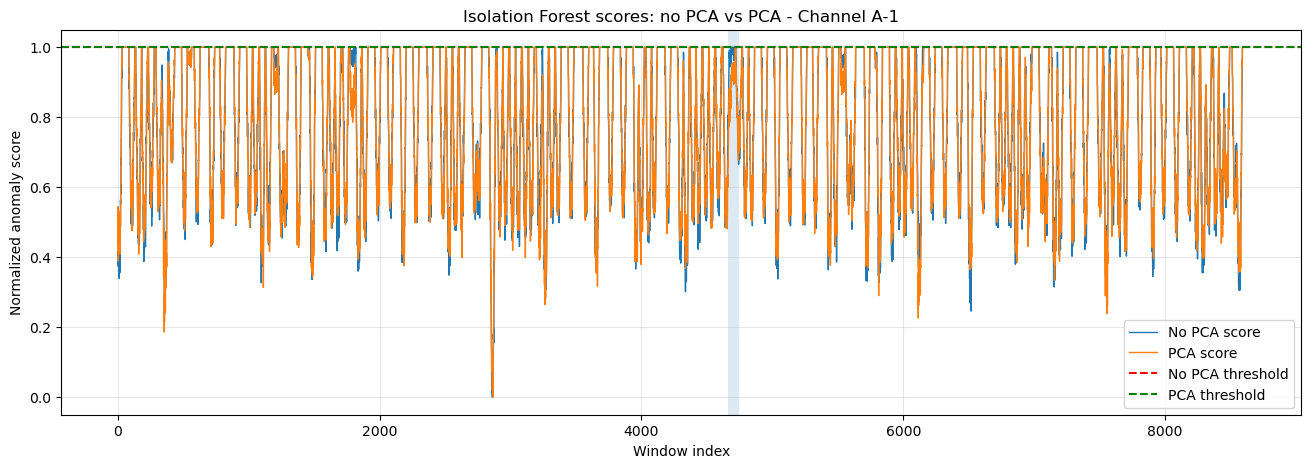

In [89]:
plot_iforest_comparison_pca_vs_no_pca(
    channel_id="A-1",
    scores_no_pca=iforest_no_pca_scores,
    scores_pca=iforest_pca_scores,
    test_data_no_pca=test_preprocessed_data,
    results_no_pca=iforest_no_pca_df,
    results_pca=iforest_pca_df
)